# Solar Photovoltaic (PV) Plant Performance Anomaly Detection
### CleanTech & Manufacturing — Predictive Maintenance for Distributed Energy Assets

**Business context.** Utility-scale solar plants are effectively distributed power-manufacturing
facilities: DC electricity is "manufactured" by panel strings and converted to AC by inverters
(the plant's core production units). Just like a factory floor, an inverter that silently
under-produces — due to soiling, string faults, shading, connector degradation, or firmware
issues — quietly erodes revenue and asset lifetime long before it triggers a hard failure alarm.

Manually checking dozens of inverters against constantly-changing weather is impractical, so this
notebook builds an automated **time-series anomaly detection pipeline** that flags abnormal
inverter/plant behavior for a real solar power plant.

**Dataset.** Real generation and weather-sensor telemetry from a solar power plant in India,
originally published on Kaggle ("Solar Power Generation Data") and used here from a public GitHub
mirror:
- `Plant_1_Generation_Data.csv` — AC/DC power and cumulative yield, **22 inverters**, 15-minute
  intervals, 34 days (15 May – 17 Jun 2020).
- `Plant_1_Weather_Sensor_Data.csv` — ambient temperature, module temperature, and solar
  irradiation at the plant, same time resolution.

**What we'll do:**
1. Load and explore the real telemetry.
2. Build a physics-informed "expected output" baseline from irradiance (a solar panel's output is
   driven almost entirely by how much sunlight hits it).
3. Detect anomalies with two complementary techniques:
   - **Residual/rolling z-score** on plant-level output vs. irradiance-expected output (classic
     statistical time-series anomaly detection).
   - **Isolation Forest** on multivariate inverter-level features (machine-learning-based
     anomaly detection, catches irregular *combinations* of variables).
4. Identify which specific inverters (production units) are driving the anomalies.
5. Quantify the estimated energy/revenue impact — the manufacturing-style "yield loss" view.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


C:\Users\frank\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


## 1. Load the real data

This notebook is self-contained: if the two CSV files aren't found in the same folder as this
notebook, the next cell downloads them automatically from the public GitHub mirror of the
Kaggle "Solar Power Generation Data" dataset. No manual download needed — just run the cells
top to bottom.

In [2]:
import os
import urllib.request

GEN_FILE = "Plant_1_Generation_Data.csv"
WEATHER_FILE = "Plant_1_Weather_Sensor_Data.csv"
BASE_URL = "https://raw.githubusercontent.com/kaivalpanchal/Solar-Panel-Power-Generation/main/"

def ensure_local(filename):
    # Download the CSV next to this notebook if it isn't already there.
    if not os.path.exists(filename):
        print(f"'{filename}' not found locally — downloading from GitHub mirror...")
        urllib.request.urlretrieve(BASE_URL + filename, filename)
        print(f"Saved {filename} ({os.path.getsize(filename):,} bytes)")
    return filename

ensure_local(GEN_FILE)
ensure_local(WEATHER_FILE)

gen = pd.read_csv(GEN_FILE)
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], format="%d-%m-%Y %H:%M")

weather = pd.read_csv(WEATHER_FILE)
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])

print(f"Generation records : {len(gen):,}  |  inverters: {gen['SOURCE_KEY'].nunique()}  "
      f"|  span: {gen['DATE_TIME'].min()} -> {gen['DATE_TIME'].max()}")
print(f"Weather records    : {len(weather):,}")
gen.head()

Generation records : 68,778  |  inverters: 22  |  span: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Weather records    : 3,182


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [3]:
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## 2. Exploratory view: plant-level output over time

We first aggregate all 22 inverters into a single plant-level AC power signal, then merge in the
weather sensor readings (irradiation is the key physical driver of output).

In [4]:
plant = (gen.groupby("DATE_TIME")
              .agg(AC_POWER=("AC_POWER", "sum"),
                   DC_POWER=("DC_POWER", "sum"),
                   N_INVERTERS_REPORTING=("SOURCE_KEY", "nunique"))
              .reset_index())

weather_small = weather[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]]
plant = plant.merge(weather_small, on="DATE_TIME", how="left").sort_values("DATE_TIME").reset_index(drop=True)
plant.head()

,DATE_TIME,AC_POWER,DC_POWER,N_INVERTERS_REPORTING,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,21,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,21,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,21,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,21,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,22,24.621525,22.165423,0.0


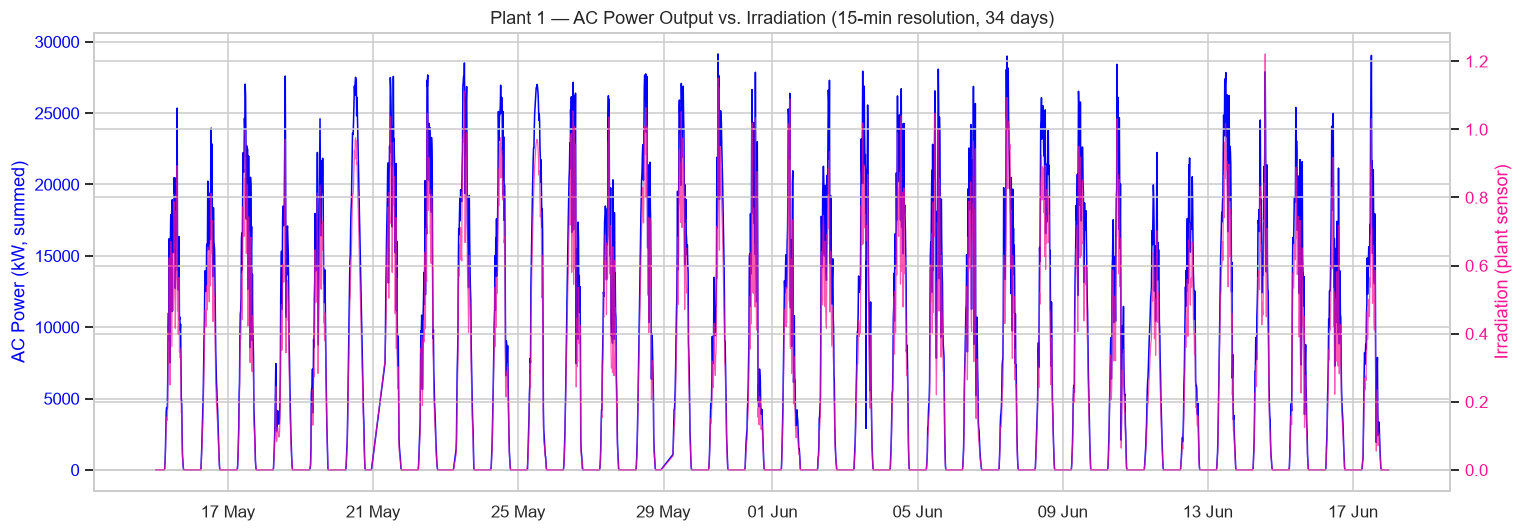

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(plant["DATE_TIME"], plant["AC_POWER"], color="blue", lw=1, label="Plant AC Power (sum of 22 inverters)")
ax1.set_ylabel("AC Power (kW, summed)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

ax2 = ax1.twinx()
ax2.plot(plant["DATE_TIME"], plant["IRRADIATION"], color="deeppink", lw=0.8, alpha=0.7, label="Irradiation")
ax2.set_ylabel("Irradiation (plant sensor)", color="deeppink")
ax2.tick_params(axis="y", labelcolor="deeppink")

plt.title("Plant 1 — AC Power Output vs. Irradiation (15-min resolution, 34 days)")
fig.tight_layout()
plt.show()

Output tracks irradiation closely, as expected for a solar plant — power should be roughly
proportional to sunlight. This tight physical coupling is exactly what we'll exploit: **any point
where the AC power deviates a lot from what irradiation predicts is a candidate anomaly**
(underperformance, curtailment, sensor fault, or an inverter outage).

## 3. Method 1 — Residual + rolling z-score anomaly detection

**Idea.** Fit a simple model of *expected* plant output as a function of irradiance and module
temperature (a lightweight proxy for a PV performance model). The residual (actual − expected)
should be small and noise-like under normal operation. We then flag time steps where the
residual's rolling z-score exceeds a threshold — a standard, interpretable statistical technique
for time-series anomaly detection.

In [6]:
daylight = plant[plant["IRRADIATION"] > 0.02].dropna(subset=["IRRADIATION", "MODULE_TEMPERATURE", "AC_POWER"]).copy()

X = daylight[["IRRADIATION", "MODULE_TEMPERATURE"]].values
y = daylight["AC_POWER"].values

expected_model = LinearRegression().fit(X, y)
daylight["EXPECTED_AC_POWER"] = expected_model.predict(X)
daylight["RESIDUAL"] = daylight["AC_POWER"] - daylight["EXPECTED_AC_POWER"]

print(f"R^2 of irradiance->power baseline model: {expected_model.score(X, y):.3f}")
daylight[["DATE_TIME", "AC_POWER", "EXPECTED_AC_POWER", "RESIDUAL"]].head()

R^2 of irradiance->power baseline model: 0.982


,DATE_TIME,AC_POWER,EXPECTED_AC_POWER,RESIDUAL
25,2020-05-15 06:15:00,593.338690,1296.653799,-703.315109
26,2020-05-15 06:30:00,1480.194643,2036.800867,-556.606224
27,2020-05-15 06:45:00,2790.448214,3301.379339,-510.931125
28,2020-05-15 07:00:00,4052.662143,4599.848568,-547.186425
29,2020-05-15 07:15:00,4368.722619,4971.070469,-602.347850


In [7]:
window = 24  # 24 * 15min = 6 hours
roll_mean = daylight["RESIDUAL"].rolling(window, min_periods=8, center=True).mean()
roll_std = daylight["RESIDUAL"].rolling(window, min_periods=8, center=True).std()
daylight["Z_SCORE"] = (daylight["RESIDUAL"] - roll_mean) / roll_std

Z_THRESHOLD = 3.0
daylight["IS_ANOMALY_STAT"] = daylight["Z_SCORE"].abs() > Z_THRESHOLD

n_anom = daylight["IS_ANOMALY_STAT"].sum()
print(f"Flagged {n_anom} anomalous 15-min intervals out of {len(daylight)} daylight readings "
      f"({n_anom/len(daylight):.1%}) using |z| > {Z_THRESHOLD}")

Flagged 9 anomalous 15-min intervals out of 1612 daylight readings (0.6%) using |z| > 3.0


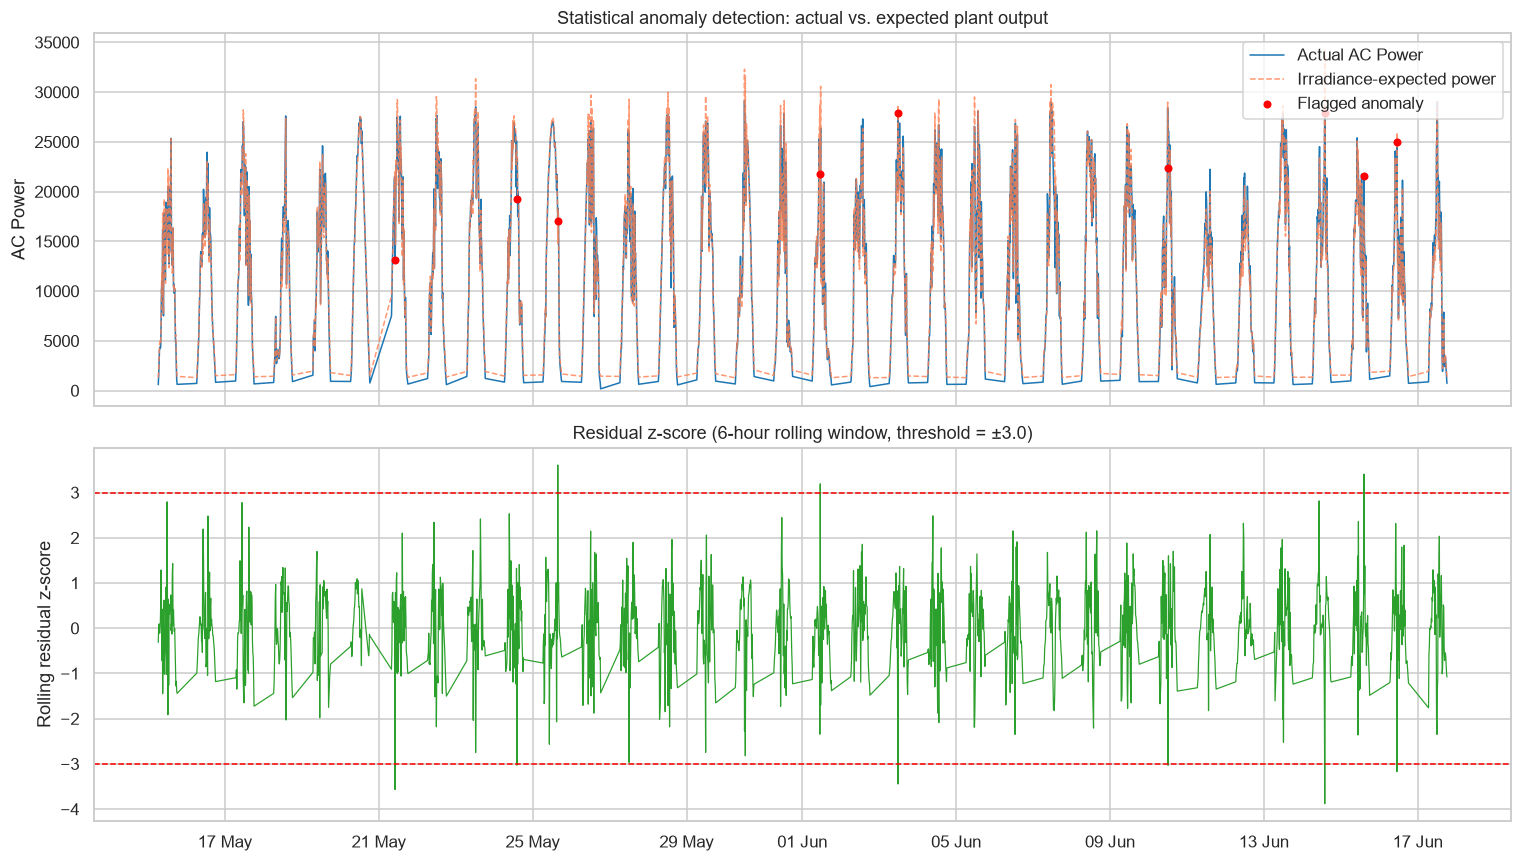

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daylight["DATE_TIME"], daylight["AC_POWER"], color="#1f77b4", lw=1, label="Actual AC Power")
axes[0].plot(daylight["DATE_TIME"], daylight["EXPECTED_AC_POWER"], color="coral", lw=1, ls="--", alpha=0.8, label="Irradiance-expected power")
anoms = daylight[daylight["IS_ANOMALY_STAT"]]
axes[0].scatter(anoms["DATE_TIME"], anoms["AC_POWER"], color="red", s=18, zorder=5, label="Flagged anomaly")
axes[0].set_ylabel("AC Power")
axes[0].set_title("Statistical anomaly detection: actual vs. expected plant output")
axes[0].legend(loc="upper right")

axes[1].plot(daylight["DATE_TIME"], daylight["Z_SCORE"], color="#2ca02c", lw=0.8)
axes[1].axhline(Z_THRESHOLD, color="red", ls="--", lw=1)
axes[1].axhline(-Z_THRESHOLD, color="red", ls="--", lw=1)
axes[1].set_ylabel("Rolling residual z-score")
axes[1].set_title(f"Residual z-score (6-hour rolling window, threshold = ±{Z_THRESHOLD})")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.show()

The statistical method catches **plant-wide** deviations well — sudden drops or spikes
relative to what the sun and panel temperature would predict. It's cheap, interpretable, and
requires no labeled data. Its main limitation: it only sees the *aggregate* signal, so a single
faulty inverter among 22 can be masked by the other 21 performing normally.

To catch inverter-level problems, we need a method that looks at each unit individually and can
combine several signals at once.

## 4. Method 2 — Isolation Forest (multivariate, inverter-level)

**Idea.** Isolation Forest is an unsupervised ML anomaly detector that isolates points via random
recursive splits — anomalies (rare, "different" combinations of feature values) require fewer
splits to isolate than normal points, giving them an anomaly score. Unlike the z-score method
above, it naturally handles **multiple correlated features at once** and works per-inverter.

Features used per (inverter, timestamp) during daylight hours:
- `AC_POWER`, `DC_POWER`
- `CONVERSION_EFFICIENCY` = AC_POWER / DC_POWER (inverter health signal — should be ~0.97–0.99)
- `IRRADIATION`, `MODULE_TEMPERATURE` (expected drivers of output)

In [9]:
gen_w = gen.merge(weather_small, on="DATE_TIME", how="left")
gen_w = gen_w[gen_w["IRRADIATION"] > 0.02].copy()  # restrict to daylight so "should be producing"

# Inverter conversion efficiency; guard against divide-by-zero
gen_w["CONVERSION_EFFICIENCY"] = np.where(gen_w["DC_POWER"] > 0,
                                           gen_w["AC_POWER"] / gen_w["DC_POWER"],
                                           0.0)

features = ["AC_POWER", "DC_POWER", "CONVERSION_EFFICIENCY", "IRRADIATION", "MODULE_TEMPERATURE"]
model_df = gen_w.dropna(subset=features).copy()

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
model_df["ANOMALY_SCORE"] = iso.fit_predict(model_df[features])          # -1 = anomaly, 1 = normal
model_df["ANOMALY_SCORE_RAW"] = iso.decision_function(model_df[features])  # lower = more anomalous
model_df["IS_ANOMALY_ML"] = model_df["ANOMALY_SCORE"] == -1

print(f"Flagged {model_df['IS_ANOMALY_ML'].sum():,} anomalous inverter-timestamp readings "
      f"out of {len(model_df):,} ({model_df['IS_ANOMALY_ML'].mean():.1%})")
model_df[features + ["IS_ANOMALY_ML"]].head()

Flagged 709 anomalous inverter-timestamp readings out of 35,428 (2.0%)


,AC_POWER,DC_POWER,CONVERSION_EFFICIENCY,IRRADIATION,MODULE_TEMPERATURE,IS_ANOMALY_ML
531,26.862500,278.000000,0.096628,0.022282,22.353459,False
532,30.014286,310.571429,0.096642,0.022282,22.353459,False
533,30.775000,318.625000,0.096587,0.022282,22.353459,False
534,30.562500,316.250000,0.096640,0.022282,22.353459,False
535,30.100000,311.428571,0.096651,0.022282,22.353459,False


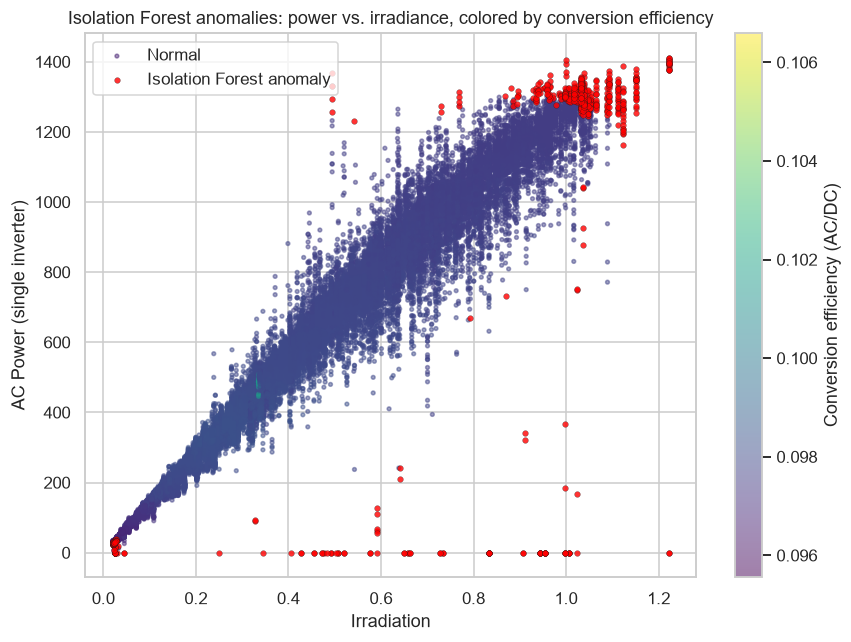

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
normal = model_df[~model_df["IS_ANOMALY_ML"]]
anomaly = model_df[model_df["IS_ANOMALY_ML"]]

sc = ax.scatter(normal["IRRADIATION"], normal["AC_POWER"], c=normal["CONVERSION_EFFICIENCY"],
                 cmap="viridis", s=6, alpha=0.5, label="Normal")
ax.scatter(anomaly["IRRADIATION"], anomaly["AC_POWER"], color="red", s=14, alpha=0.8,
           edgecolor="k", linewidth=0.2, label="Isolation Forest anomaly")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Conversion efficiency (AC/DC)")
ax.set_xlabel("Irradiation")
ax.set_ylabel("AC Power (single inverter)")
ax.set_title("Isolation Forest anomalies: power vs. irradiance, colored by conversion efficiency")
ax.legend()
plt.tight_layout()
plt.show()

Anomalies cluster in two intuitive regions: **high irradiance with near-zero power**
(an inverter/string that should be producing but isn't — e.g. a tripped inverter or DC-side fault)
and **abnormal conversion efficiency** (an inverter converting DC to AC unusually inefficiently,
a classic early sign of inverter degradation).

## 5. Which inverters are actually driving the anomalies?

This is the "which machine on the factory floor" question — turning a generic anomaly count into
an actionable maintenance target list.

In [11]:
inv_summary = (model_df.groupby("SOURCE_KEY")
               .agg(readings=("IS_ANOMALY_ML", "size"),
                    anomalies=("IS_ANOMALY_ML", "sum"),
                    mean_efficiency=("CONVERSION_EFFICIENCY", "mean"))
               .assign(anomaly_rate=lambda d: d["anomalies"] / d["readings"])
               .sort_values("anomaly_rate", ascending=False))

inv_summary.head(10)

,readings,anomalies,mean_efficiency,anomaly_rate
SOURCE_KEY,,,,
adLQvlD726eNBSB,1605,49,0.097765,0.030530
bvBOhCH3iADSZry,1612,46,0.096451,0.028536
1BY6WEcLGh8j5v7,1611,44,0.096627,0.027312
3PZuoBAID5Wc2HD,1605,41,0.097764,0.025545
wCURE6d3bPkepu2,1612,41,0.097403,0.025434
McdE0feGgRqW7Ca,1612,36,0.097528,0.022333
z9Y9gH1T5YWrNuG,1612,36,0.097284,0.022333
ZnxXDlPa8U1GXgE,1610,35,0.097709,0.021739
iCRJl6heRkivqQ3,1612,35,0.097645,0.021712


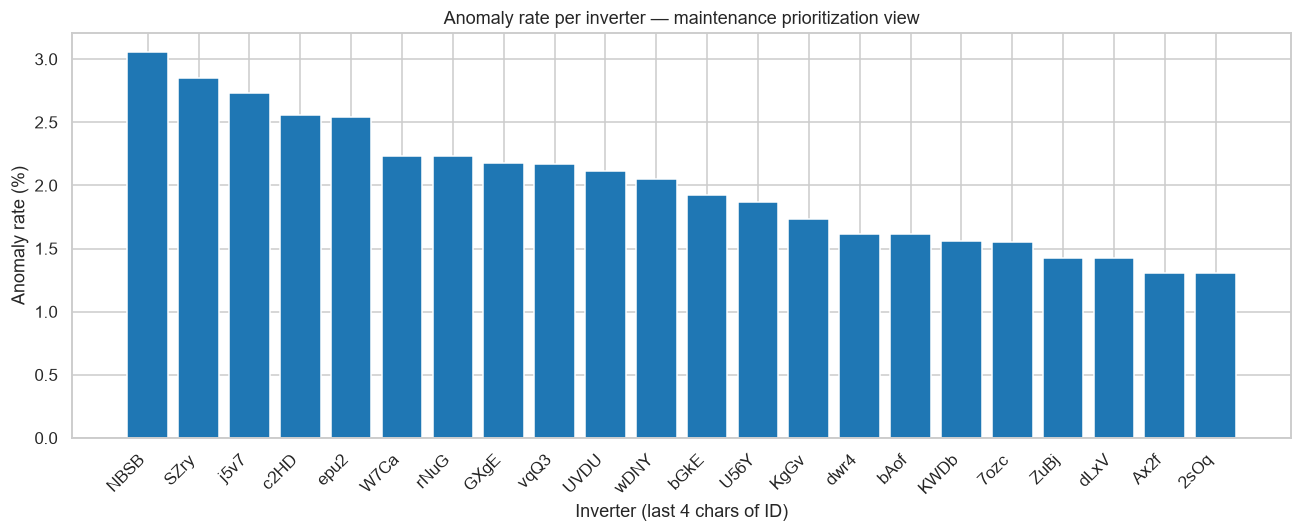

Highest-priority inverter for inspection: adLQvlD726eNBSB (anomaly rate 3.1%, mean conversion efficiency 0.098)


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
top = inv_summary.sort_values("anomaly_rate", ascending=False)
colors = ["#d62728" if r > top["anomaly_rate"].median() * 2 else "#1f77b4" for r in top["anomaly_rate"]]
ax.bar(range(len(top)), top["anomaly_rate"] * 100, color=colors)
ax.set_xticks(range(len(top)))
ax.set_xticklabels([s[-4:] for s in top.index], rotation=45, ha="right")
ax.set_ylabel("Anomaly rate (%)")
ax.set_xlabel("Inverter (last 4 chars of ID)")
ax.set_title("Anomaly rate per inverter — maintenance prioritization view")
plt.tight_layout()
plt.show()

worst = inv_summary.index[0]
print(f"Highest-priority inverter for inspection: {worst} "
      f"(anomaly rate {inv_summary.loc[worst, 'anomaly_rate']:.1%}, "
      f"mean conversion efficiency {inv_summary.loc[worst, 'mean_efficiency']:.3f})")

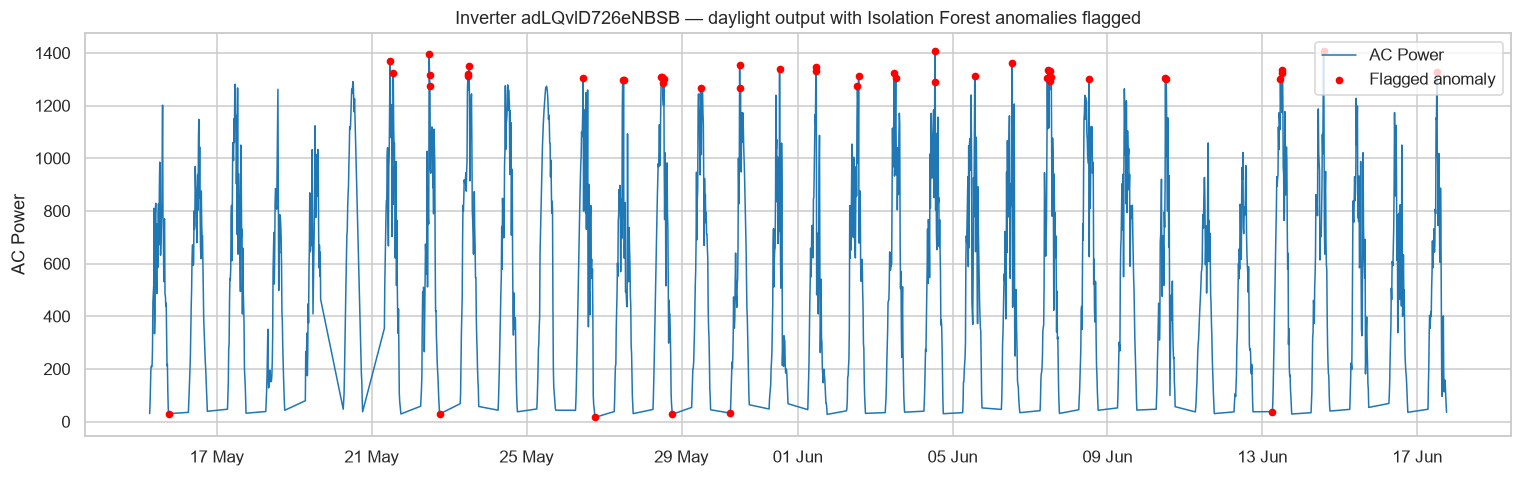

In [13]:
worst_df = model_df[model_df["SOURCE_KEY"] == worst].sort_values("DATE_TIME")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(worst_df["DATE_TIME"], worst_df["AC_POWER"], lw=1, color="#1f77b4", label="AC Power")
flagged = worst_df[worst_df["IS_ANOMALY_ML"]]
ax.scatter(flagged["DATE_TIME"], flagged["AC_POWER"], color="red", s=16, zorder=5, label="Flagged anomaly")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("AC Power")
ax.set_title(f"Inverter {worst} — daylight output with Isolation Forest anomalies flagged")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Estimated impact — turning anomalies into a "yield loss" number

The manufacturing framing of this problem is: every 15-minute interval an inverter *should* have
been producing power (irradiance > 0) but wasn't, at the rate irradiance/temperature predicts, is
lost production — directly analogous to unplanned downtime on a production line.

In [14]:
# Expected power per inverter-reading using the same physics-informed regression as Method 1,
# now applied at inverter level for readings flagged by Isolation Forest.
X_all = model_df[["IRRADIATION", "MODULE_TEMPERATURE"]].values
model_df["EXPECTED_AC_POWER_INV"] = expected_model.predict(X_all) / gen["SOURCE_KEY"].nunique()

flagged_readings = model_df[model_df["IS_ANOMALY_ML"] & (model_df["AC_POWER"] < model_df["EXPECTED_AC_POWER_INV"])]
lost_power_kw_intervals = (flagged_readings["EXPECTED_AC_POWER_INV"] - flagged_readings["AC_POWER"]).clip(lower=0)

# 15-minute intervals -> convert kW to kWh
lost_energy_kwh = (lost_power_kw_intervals * 0.25).sum()

print(f"Anomalous under-production intervals: {len(flagged_readings):,}")
print(f"Estimated lost energy over the {plant['DATE_TIME'].dt.date.nunique()}-day window: "
      f"{lost_energy_kwh:,.0f} kWh")
print("(Illustrative estimate from a simple irradiance/temperature baseline — a production "
      "system would use a calibrated PV performance model, e.g. PVWatts/PVLib.)")

Anomalous under-production intervals: 554
Estimated lost energy over the 34-day window: 26,009 kWh
(Illustrative estimate from a simple irradiance/temperature baseline — a production system would use a calibrated PV performance model, e.g. PVWatts/PVLib.)


## 7. Summary & takeaways

- **Real telemetry, real physics.** Solar output should track irradiance tightly; treating the
  irradiance→power relationship as a baseline turns "anomaly detection" into "is this deviating
  from physics," which is far more robust than looking at raw power alone.
- **Two complementary detectors:**
  - *Rolling z-score on residuals* — simple, transparent, great for plant-wide events (grid
    curtailment, sensor outages, cloud-cover misattribution).
  - *Isolation Forest* — multivariate, catches inverter-specific issues (low conversion
    efficiency, silent underperformance) that a single aggregate signal would hide.
- **Actionable output.** Ranking inverters by anomaly rate converts a stream of flagged points
  into a **maintenance work order list** — exactly the workflow a CleanTech operations team or
  manufacturing-adjacent asset-management system needs.
- **Business framing.** Converting flagged anomalies into estimated lost kWh connects the
  data-science output directly to revenue/OPEX — the language operations and finance stakeholders
  care about.

**Next steps for a production system:** use a calibrated PV performance model (e.g., `pvlib`)
instead of a linear baseline, incorporate soiling/shading models, add per-inverter historical
comparison (inverter vs. its own trailing baseline, not just plant-wide), and feed flagged
anomalies into a ticketing/CMMS system for field technician dispatch.